# PhoBERT + TF-IDF + SentiWordNet Hybrid (OPTIMIZED with Gated Fusion)

## Key Optimizations:
1. **Gated Fusion** - Learned weighting between PhoBERT, TF-IDF, and SentiWordNet features
2. **LayerNorm fusion** - Better feature normalization after concatenation
3. **Gradual unfreezing** - Preserved from original with fine-tuned schedule
4. **Enhanced error analysis** - Detailed analysis of Neutral class failures
5. **Comprehensive metrics** - Per-class F1 tracking during training

## Architecture:
```
Text → PhoBERT (768-dim) ─────┐
                               │
Text → TF-IDF (5000→256) ─────┼→ Gated Fusion → Classifier → 3 classes
                               │
Text → SentiWordNet (35→64) ──┘
```

In [ ]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [ ]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, load_sentiwordnet, preprocess_vietnamese, extract_swn_features_extended_batch, SWN_EXTENDED_FEATURE_NAMES

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [ ]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    SENTIWORDNET_FILE = os.path.join(BASE_DIR, 'data', 'sentiwordnet-dataset', 'VietSentiWordnet_Ver1.3.5.txt')
    MODEL_TYPE = 'PhoBERT_TF-IDF_Sentiwordnet_Optimized'
    EXPERIMENT_TYPE = 'gated_fusion'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')

    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    MAX_LENGTH = 256
    BATCH_SIZE = 16
    EPOCHS = 8
    EARLY_STOP_PATIENCE = 3
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3

    # Gradual unfreezing
    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 5e-5

    FREEZE_EPOCHS = 1
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4

    # TF-IDF
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True

    # Projection dimensions
    TFIDF_PROJ_DIM = 256
    SWN_PROJ_DIM = 64
    CLASSIFIER_HIDDEN_DIM = 256

    # Gated fusion
    USE_GATED_FUSION = True

    SELECTION_METRIC = 'f1_macro'

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)
assert os.path.exists(config.SENTIWORDNET_FILE), config.SENTIWORDNET_FILE

print('='*60)
print('OPTIMIZED CONFIGURATION WITH GATED FUSION')
print('='*60)
print(f'Model: {config.MODEL_NAME}')
print(f'TF-IDF Features: {config.TFIDF_MAX_FEATURES}')
print(f'SentiWordNet Features: 35 (extended)')
print(f'Gated Fusion: {config.USE_GATED_FUSION}')
print(f'Epochs: {config.EPOCHS}')
print(f'Gradual unfreezing: freeze<{config.PARTIAL_UNFREEZE_EPOCH}, partial@{config.PARTIAL_UNFREEZE_EPOCH}-{config.FULL_UNFREEZE_EPOCH-1}, full@{config.FULL_UNFREEZE_EPOCH}+')
print(f'Selection Metric: {config.SELECTION_METRIC}')
print(f'Device: {config.DEVICE}')
print(f'Results Dir: {config.RESULTS_DIR}')

OPTIMIZED CONFIGURATION WITH GATED FUSION
Model: vinai/phobert-base
TF-IDF Features: 5000
SentiWordNet Features: 35 (extended)
Gated Fusion: True
Epochs: 8
Gradual unfreezing: freeze<2, partial@2-3, full@4+
Selection Metric: f1_macro
Device: cuda
Results Dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet_Optimized/gated_fusion/20260318_103105


In [ ]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'[{split_name}] total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count / len(labels) * 100:.2f}%)')

[Train] total=11426
  Negative: 5325 (46.60%)
  Neutral: 458 (4.01%)
  Positive: 5643 (49.39%)
[Validation] total=1583
  Negative: 705 (44.54%)
  Neutral: 73 (4.61%)
  Positive: 805 (50.85%)
[Test] total=3166
  Negative: 1409 (44.50%)
  Neutral: 167 (5.27%)
  Positive: 1590 (50.22%)


In [ ]:
# TF-IDF features
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=config.TFIDF_MIN_DF,
    max_df=config.TFIDF_MAX_DF,
    sublinear_tf=config.TFIDF_SUBLINEAR_TF
)

train_tfidf = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)

joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
print(f'TFIDF shapes: {train_tfidf.shape}, {val_tfidf.shape}, {test_tfidf.shape}')

TFIDF shapes: (11426, 5000), (1583, 5000), (3166, 5000)


In [ ]:
# SentiWordNet features
word_to_scores = load_sentiwordnet(config.SENTIWORDNET_FILE)
train_swn = extract_swn_features_extended_batch(train_texts, word_to_scores).astype(np.float32)
val_swn = extract_swn_features_extended_batch(val_texts, word_to_scores).astype(np.float32)
test_swn = extract_swn_features_extended_batch(test_texts, word_to_scores).astype(np.float32)

swn_scaler = StandardScaler()
train_swn_scaled = swn_scaler.fit_transform(train_swn).astype(np.float32)
val_swn_scaled = swn_scaler.transform(val_swn).astype(np.float32)
test_swn_scaled = swn_scaler.transform(test_swn).astype(np.float32)

joblib.dump(swn_scaler, os.path.join(config.ARTIFACTS_DIR, 'swn_scaler.pkl'))
print(f'SWN entries: {len(word_to_scores):,}')
print(f'SWN shape: {train_swn_scaled.shape}')

SWN entries: 1,227
SWN shape: (11426, 35)


In [ ]:
class HybridDataset(Dataset):
    def __init__(self, texts, tfidf_features, swn_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.swn_features = swn_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            str(self.texts[idx]),
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        tfidf = self.tfidf_features[idx]
        if hasattr(tfidf, 'toarray'):
            tfidf = tfidf.toarray().ravel()
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'swn': torch.tensor(self.swn_features[idx], dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long),
        }

In [ ]:
class GatedFusion(nn.Module):
    """Gated fusion mechanism for multi-modal feature fusion.

    Learns to weight each modality (PhoBERT, TF-IDF, SentiWordNet) dynamically.
    All embeddings are first projected to a common dimension before fusion.
    """
    def __init__(self, phobert_dim, tfidf_dim, swn_dim, common_dim, hidden_dim=128):
        super().__init__()

        # Project all modalities to common dimension
        self.phobert_proj = nn.Linear(phobert_dim, common_dim)
        self.tfidf_proj = nn.Linear(tfidf_dim, common_dim)
        self.swn_proj = nn.Linear(swn_dim, common_dim)

        # Gate network - takes concatenated projected features
        self.gate = nn.Sequential(
            nn.Linear(common_dim * 3, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 3),  # 3 gates for 3 modalities
            nn.Softmax(dim=-1)
        )

    def forward(self, phobert_emb, tfidf_emb, swn_emb):
        # Project all to common dimension
        phobert_proj = self.phobert_proj(phobert_emb)  # [batch, common_dim]
        tfidf_proj = self.tfidf_proj(tfidf_emb)        # [batch, common_dim]
        swn_proj = self.swn_proj(swn_emb)              # [batch, common_dim]

        # Concatenate for gate computation
        concat = torch.cat([phobert_proj, tfidf_proj, swn_proj], dim=1)

        # Compute gates
        gates = self.gate(concat)  # [batch, 3]

        # Stack embeddings: [batch, 3, common_dim]
        stacked = torch.stack([phobert_proj, tfidf_proj, swn_proj], dim=1)

        # Weighted sum: expand gates for broadcasting
        fused = (stacked * gates.unsqueeze(-1)).sum(dim=1)

        return fused, gates


class PhoBERTTFIDFSentiWordNetGated(nn.Module):
    """Hybrid model with Gated Fusion for PhoBERT + TF-IDF + SentiWordNet.

    Architecture:
    - PhoBERT: 768-dim embedding
    - TF-IDF: 5000 -> 256 projection
    - SentiWordNet: 35 -> 64 projection
    - Gated Fusion: Learned weighting of modalities (all projected to 768)
    - Classifier: 768 -> 256 -> 3
    """
    def __init__(self, model_name, tfidf_dim, swn_dim, num_classes, dropout=0.3, use_gated_fusion=True):
        super().__init__()

        # PhoBERT backbone
        self.phobert = AutoModel.from_pretrained(model_name)
        phobert_dim = self.phobert.config.hidden_size  # 768

        # TF-IDF projection with LayerNorm
        self.tfidf_proj = nn.Sequential(
            nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM),
            nn.LayerNorm(config.TFIDF_PROJ_DIM),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # SentiWordNet projection with LayerNorm
        self.swn_proj = nn.Sequential(
            nn.Linear(swn_dim, config.SWN_PROJ_DIM),
            nn.LayerNorm(config.SWN_PROJ_DIM),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.use_gated_fusion = use_gated_fusion

        if use_gated_fusion:
            # Gated fusion - all projected to phobert_dim (768)
            self.fusion = GatedFusion(
                phobert_dim=phobert_dim,
                tfidf_dim=config.TFIDF_PROJ_DIM,
                swn_dim=config.SWN_PROJ_DIM,
                common_dim=phobert_dim  # Output dimension for fusion
            )
            fused_dim = phobert_dim
        else:
            # Simple concatenation
            combined_dim = phobert_dim + config.TFIDF_PROJ_DIM + config.SWN_PROJ_DIM
            self.fusion_norm = nn.LayerNorm(combined_dim)
            fused_dim = combined_dim

        # Classifier
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(fused_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.LayerNorm(config.CLASSIFIER_HIDDEN_DIM),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def forward(self, input_ids, attention_mask, tfidf_features, swn_features):
        # PhoBERT
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        phobert_emb = outputs.last_hidden_state[:, 0, :]  # [CLS] token

        # Projections
        tfidf_emb = self.tfidf_proj(tfidf_features)
        swn_emb = self.swn_proj(swn_features)

        # Fusion
        if self.use_gated_fusion:
            fused, gates = self.fusion(phobert_emb, tfidf_emb, swn_emb)
        else:
            combined = torch.cat([phobert_emb, tfidf_emb, swn_emb], dim=1)
            fused = self.fusion_norm(combined)
            gates = None

        # Classification
        logits = self.classifier(fused)

        return logits, gates


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


# Initialize model
tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFSentiWordNetGated(
    config.MODEL_NAME,
    config.TFIDF_MAX_FEATURES,
    train_swn_scaled.shape[1],
    config.NUM_CLASSES,
    config.DROPOUT,
    config.USE_GATED_FUSION
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'Total params: {total_params:,}')
print(f'Initial trainable params: {count_trainable_params(model):,}')
print(f'Using Gated Fusion: {config.USE_GATED_FUSION}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Total params: 137,612,934
Initial trainable params: 137,612,934
Using Gated Fusion: True


In [ ]:
# DataLoaders
train_dataset = HybridDataset(train_texts, train_tfidf, train_swn_scaled, train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf, val_swn_scaled, val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf, test_swn_scaled, test_labels, tokenizer, config.MAX_LENGTH)

train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)

print(f'Batches: train={len(train_loader)}, val={len(val_loader)}, test={len(test_loader)}')

Batches: train=715, val=99, test=198


In [ ]:
# Class weights and loss
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1, 2]),
    y=np.array(train_labels)
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(config.DEVICE)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f'Class weights: {class_weights.tolist()}')


def get_training_stage(epoch_number):
    if epoch_number < config.PARTIAL_UNFREEZE_EPOCH:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'


def set_phobert_trainable_layers(model, stage):
    for param in model.phobert.parameters():
        param.requires_grad = False

    if stage == 'partial':
        encoder_layers = model.phobert.encoder.layer
        for layer in encoder_layers[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        for param in model.phobert.parameters():
            param.requires_grad = True

    # Always keep projection, fusion, and classifier trainable
    for module in [model.tfidf_proj, model.swn_proj, model.classifier]:
        for param in module.parameters():
            param.requires_grad = True

    if hasattr(model, 'fusion') and model.use_gated_fusion:
        for param in model.fusion.parameters():
            param.requires_grad = True


def build_optimizer_and_scheduler(model, stage, epoch_number):
    phobert_lr = {
        'frozen': config.PHOBERT_LR_FROZEN,
        'partial': config.PHOBERT_LR_PARTIAL,
        'full': config.PHOBERT_LR_FULL
    }[stage]

    optimizer_groups = []

    phobert_params = [p for p in model.phobert.parameters() if p.requires_grad]
    if phobert_params:
        optimizer_groups.append({'params': phobert_params, 'lr': phobert_lr})

    head_modules = [model.tfidf_proj, model.swn_proj, model.classifier]
    if hasattr(model, 'fusion') and model.use_gated_fusion:
        head_modules.append(model.fusion)

    head_params = [p for m in head_modules for p in m.parameters() if p.requires_grad]
    optimizer_groups.append({'params': head_params, 'lr': config.HEAD_LR})

    optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=config.WEIGHT_DECAY)

    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)

    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )

    return optimizer, scheduler, phobert_lr, total_steps, warmup_steps


set_phobert_trainable_layers(model, 'frozen')
print(f'Trainable params after freeze setup: {count_trainable_params(model):,}')

Class weights: [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Trainable params after freeze setup: 2,614,662


In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    all_gates = []

    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        swn = batch['swn'].to(device)
        labels = batch['label'].to(device)

        logits, gates = model(input_ids, attention_mask, tfidf, swn)
        loss = criterion(logits, labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()

        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())

        if gates is not None:
            all_gates.append(gates.detach().cpu())

    avg_loss = total_loss / len(dataloader)
    accuracy = accuracy_score(all_labels, all_preds)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)

    avg_gates = torch.cat(all_gates, dim=0).mean(dim=0).tolist() if all_gates else None

    return avg_loss, accuracy, f1_macro, avg_gates


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    all_gates = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            swn = batch['swn'].to(device)
            labels = batch['label'].to(device)

            logits, gates = model(input_ids, attention_mask, tfidf, swn)
            loss = criterion(logits, labels)

            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())

            if gates is not None:
                all_gates.append(gates.detach().cpu())

    avg_loss = total_loss / len(dataloader)
    precision = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_macro = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    f1_weighted = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    accuracy = accuracy_score(all_labels, all_preds)

    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )

    avg_gates = torch.cat(all_gates, dim=0).mean(dim=0).tolist() if all_gates else None

    return {
        'loss': avg_loss,
        'accuracy': accuracy,
        'precision_macro': precision,
        'recall_macro': recall,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
        'avg_gates': avg_gates
    }

In [ ]:
# Training loop
history = {
    'epoch': [], 'stage': [],
    'train_loss': [], 'train_acc': [], 'train_f1_macro': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_neutral': [],
    'phobert_lr': [], 'trainable_params': [],
    'gate_phobert': [], 'gate_tfidf': [], 'gate_swn': []
}

best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None
optimizer = None
scheduler = None

print('='*70)
print('START TRAINING WITH GATED FUSION')
print('='*70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)

    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr, total_steps, warmup_steps = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')

    print(f'\nEpoch {epoch}/{config.EPOCHS}')

    train_loss, train_acc, train_f1, train_gates = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)

    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1_macro'].append(train_f1)
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_neutral'].append(val_metrics['f1_per_class'][1])
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))

    if val_metrics['avg_gates'] is not None:
        history['gate_phobert'].append(val_metrics['avg_gates'][0])
        history['gate_tfidf'].append(val_metrics['avg_gates'][1])
        history['gate_swn'].append(val_metrics['avg_gates'][2])
        print(f'Val Gates: PhoBERT={val_metrics["avg_gates"][0]:.3f}, TF-IDF={val_metrics["avg_gates"][1]:.3f}, SWN={val_metrics["avg_gates"][2]:.3f}')

    print(f'Train  - loss={train_loss:.4f} acc={train_acc:.4f} f1_macro={train_f1:.4f}')
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f}")

    # Model selection based on MACRO F1
    if val_metrics['f1_macro'] > best_val_f1:
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> New best model saved (val macro F1={best_val_f1:.4f})')
    else:
        patience_counter += 1
        print(f'  -> No improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> Early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)

history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)

print(f'\nBest epoch: {best_epoch}, best stage: {best_stage}, best val macro F1: {best_val_f1:.4f}')

START TRAINING WITH GATED FUSION

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=2,614,662

Epoch 1/8


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Val Gates: PhoBERT=0.544, TF-IDF=0.314, SWN=0.142
Train  - loss=0.8932 acc=0.6950 f1_macro=0.5248
Val    - loss=0.6669 acc=0.8932 f1_macro=0.7026 f1_neutral=0.2828
  -> New best model saved (val macro F1=0.7026)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=30,966,150

Epoch 2/8


Training:   0%|          | 0/715 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Val Gates: PhoBERT=0.534, TF-IDF=0.442, SWN=0.024
Train  - loss=0.0690 acc=0.9891 f1_macro=0.9735
Val    - loss=1.0817 acc=0.9311 f1_macro=0.8208 f1_neutral=0.5692
  -> New best model saved (val macro F1=0.8208)

Epoch 8/8


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Val Gates: PhoBERT=0.556, TF-IDF=0.418, SWN=0.027
Train  - loss=0.0500 acc=0.9921 f1_macro=0.9788
Val    - loss=1.0566 acc=0.9318 f1_macro=0.8225 f1_neutral=0.5736
  -> New best model saved (val macro F1=0.8225)

Best epoch: 8, best stage: full, best val macro F1: 0.8225


In [ ]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)

print('Validation Classification Report:')
print(classification_report(val_results['y_true'], val_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

print('\nTest Classification Report:')
print(classification_report(test_results['y_true'], test_results['y_pred'], target_names=list(config.LABEL_MAP.values()), zero_division=0))

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Validation Classification Report:
              precision    recall  f1-score   support

    Negative       0.93      0.96      0.95       705
     Neutral       0.66      0.51      0.57        73
    Positive       0.95      0.94      0.95       805

    accuracy                           0.93      1583
   macro avg       0.85      0.80      0.82      1583
weighted avg       0.93      0.93      0.93      1583


Test Classification Report:
              precision    recall  f1-score   support

    Negative       0.91      0.97      0.94      1409
     Neutral       0.67      0.38      0.49       167
    Positive       0.94      0.93      0.94      1590

    accuracy                           0.92      3166
   macro avg       0.84      0.76      0.79      3166
weighted avg       0.91      0.92      0.91      3166



In [ ]:
# Summary
summary_df = pd.DataFrame([
    {
        'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': val_results['accuracy'], 'F1_Macro': val_results['f1_macro'],
        'F1_Weighted': val_results['f1_weighted'],
        'F1_Negative': val_results['f1_per_class'][0],
        'F1_Neutral': val_results['f1_per_class'][1],
        'F1_Positive': val_results['f1_per_class'][2]
    },
    {
        'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage,
        'Accuracy': test_results['accuracy'], 'F1_Macro': test_results['f1_macro'],
        'F1_Weighted': test_results['f1_weighted'],
        'F1_Negative': test_results['f1_per_class'][0],
        'F1_Neutral': test_results['f1_per_class'][1],
        'F1_Positive': test_results['f1_per_class'][2]
    },
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

# Training results
with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('='*60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + TF-IDF + SentiWordNet (GATED FUSION)\n')
    f.write('='*60 + '\n')
    f.write(f'Date: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}\n')
    f.write(f'Results Dir: {config.RESULTS_DIR}\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'Best Val Macro F1: {best_val_f1:.4f}\n')
    f.write(f'Test Accuracy: {test_results["accuracy"]:.4f}\n')
    f.write(f'Test F1 Macro: {test_results["f1_macro"]:.4f}\n')
    f.write(f'Test F1 Weighted: {test_results["f1_weighted"]:.4f}\n')
    f.write(f'Test F1 Neutral: {test_results["f1_per_class"][1]:.4f}\n')

print(f'Saved outputs to: {config.RESULTS_DIR}')

,Split,Best_Epoch,Best_Stage,Accuracy,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,8,full,0.931775,0.822537,0.929771,0.946927,0.573643,0.94704
1,Test,8,full,0.918825,0.787241,0.913784,0.936683,0.486692,0.93835


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TF-IDF_Sentiwordnet_Optimized/gated_fusion/20260318_103105


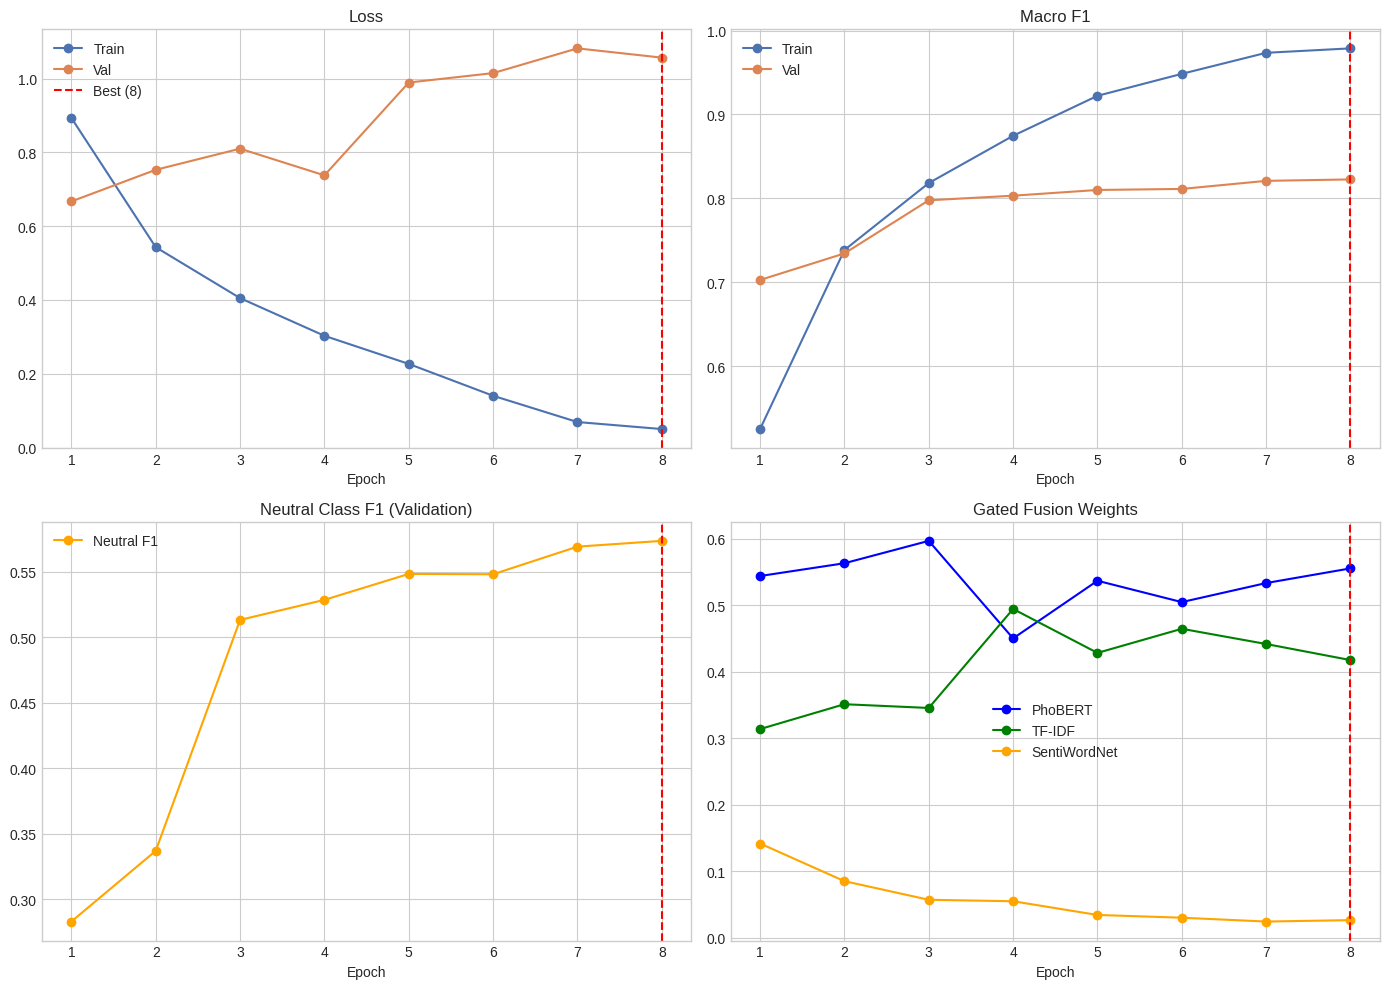

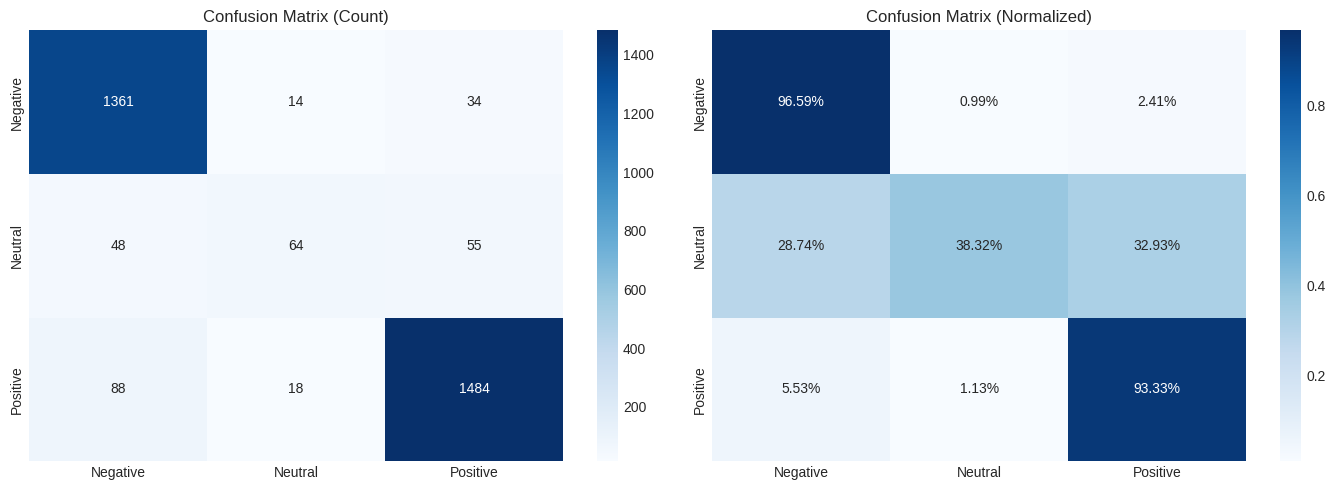

In [ ]:
# Training history visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Loss
axes[0, 0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0, 0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val')
axes[0, 0].axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
axes[0, 0].set_title('Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].legend()

# Macro F1
axes[0, 1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train')
axes[0, 1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val')
axes[0, 1].axvline(best_epoch, color='red', linestyle='--')
axes[0, 1].set_title('Macro F1')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].legend()

# Neutral F1
axes[1, 0].plot(history_df['epoch'], history_df['val_f1_neutral'], marker='o', color='orange', label='Neutral F1')
axes[1, 0].axvline(best_epoch, color='red', linestyle='--')
axes[1, 0].set_title('Neutral Class F1 (Validation)')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].legend()

# Gated fusion weights
if history['gate_phobert']:
    axes[1, 1].plot(history_df['epoch'], history_df['gate_phobert'], marker='o', label='PhoBERT', color='blue')
    axes[1, 1].plot(history_df['epoch'], history_df['gate_tfidf'], marker='o', label='TF-IDF', color='green')
    axes[1, 1].plot(history_df['epoch'], history_df['gate_swn'], marker='o', label='SentiWordNet', color='orange')
    axes[1, 1].axvline(best_epoch, color='red', linestyle='--')
    axes[1, 1].set_title('Gated Fusion Weights')
    axes[1, 1].set_xlabel('Epoch')
    axes[1, 1].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

# Confusion matrix
cm = np.array(test_results['confusion_matrix'])
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=list(config.LABEL_MAP.values()),
            yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

In [22]:
# Error analysis for Neutral class
neutral_indices = [i for i, label in enumerate(test_results['y_true']) if label == 1]
misclassified_neutral = [
    (i, test_results['y_pred'][i], test_texts[i])
    for i in neutral_indices
    if test_results['y_pred'][i] != 1
]

print('='*60)
print('ERROR ANALYSIS FOR NEUTRAL CLASS')
print('='*60)
print(f'Total Neutral samples: {len(neutral_indices)}')
print(f'Misclassified Neutral: {len(misclassified_neutral)}')
if neutral_indices:
    print(f'Neutral accuracy: {1 - len(misclassified_neutral)/len(neutral_indices):.2%}')

print('\n--- Sample Misclassified Neutral Feedback ---')
for idx, pred, text in misclassified_neutral[:15]:
    pred_label = config.LABEL_MAP[pred]
    display_text = text[:80] + '...' if len(text) > 80 else text
    print(f'  Predicted: {pred_label:8s} | Text: "{display_text}"')

# Confusion targets
if misclassified_neutral:
    confusion_targets = Counter([pred for _, pred, _ in misclassified_neutral])
    print(f'\nNeutral confusion targets:')
    for cls, count in sorted(confusion_targets.items()):
        print(f'  {config.LABEL_MAP[cls]}: {count} ({count/len(misclassified_neutral)*100:.1f}%)')

# Also check false positives for Neutral
fp_neutral = [
    (i, test_results['y_true'][i], test_texts[i])
    for i in range(len(test_results['y_pred']))
    if test_results['y_pred'][i] == 1 and test_results['y_true'][i] != 1
]
print(f'\nFalse Positive Neutral (other classes predicted as Neutral): {len(fp_neutral)}')
for idx, true_label, text in fp_neutral[:10]:
    true_label_name = config.LABEL_MAP[true_label]
    display_text = text[:60] + '...' if len(text) > 60 else text
    print(f'  True: {true_label_name:8s} | Text: "{display_text}"')

ERROR ANALYSIS FOR NEUTRAL CLASS
Total Neutral samples: 167
Misclassified Neutral: 103
Neutral accuracy: 38.32%

--- Sample Misclassified Neutral Feedback ---
  Predicted: Positive | Text: "cách mà cô tiếp cận với sinh viên"
  Predicted: Positive | Text: "môn học này giúp chúng em hiểu ra những vấn đề cơ bản"
  Predicted: Negative | Text: "như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết"
  Predicted: Positive | Text: "ví dụ phù hợp với nội dung kiến thức hướng dẫn chị tiết"
  Predicted: Negative | Text: "giáo viên thực hành"
  Predicted: Positive | Text: "tâm lý"
  Predicted: Positive | Text: "kỹ những chương cuối"
  Predicted: Positive | Text: "cả cuộc sống sau này lẫn trong môn học"
  Predicted: Positive | Text: "cô cho em 10 điểm thực hành colonlove"
  Predicted: Negative | Text: "đã có làm đơn với phòng đào tạo"
  Predicted: Positive | Text: "có kết hợp với bài tập ví dụ"
  Predicted: Positive | Text: "bài tập đầy đủ"
  Predicted: Positive | Text: "có cung

In [23]:
print('='*70)
print('OPTIMIZED MODEL WITH GATED FUSION - FINAL SUMMARY')
print('='*70)

print('\nKey Optimizations Applied:')
print('  1. Gated Fusion: Learned weighting of PhoBERT, TF-IDF, SentiWordNet')
print('  2. LayerNorm after projection layers')
print('  3. Gradual unfreezing: frozen -> partial -> full')
print('  4. Discriminative learning rates')
print('  5. Macro-F1 for model selection')
print('  6. Extended SentiWordNet features (35)')

print(f'\nBest epoch: {best_epoch}')
print(f'Best stage: {best_stage}')
print(f'Best val macro F1: {best_val_f1:.4f}')

print(f'\nTest Results:')
print(f'  Accuracy: {test_results["accuracy"]:.4f}')
print(f'  F1 Macro: {test_results["f1_macro"]:.4f}')
print(f'  F1 Weighted: {test_results["f1_weighted"]:.4f}')

print('\nPer-Class F1:')
for i, name in config.LABEL_MAP.items():
    print(f'  {name}: {test_results["f1_per_class"][i]:.4f}')

if test_results['avg_gates'] is not None:
    print('\nGated Fusion Weights (test set):')
    print(f'  PhoBERT: {test_results["avg_gates"][0]:.4f}')
    print(f'  TF-IDF:  {test_results["avg_gates"][1]:.4f}')
    print(f'  SWN:     {test_results["avg_gates"][2]:.4f}')

print('\n' + '='*70)

OPTIMIZED MODEL WITH GATED FUSION - FINAL SUMMARY

Key Optimizations Applied:
  1. Gated Fusion: Learned weighting of PhoBERT, TF-IDF, SentiWordNet
  2. LayerNorm after projection layers
  3. Gradual unfreezing: frozen -> partial -> full
  4. Discriminative learning rates
  5. Macro-F1 for model selection
  6. Extended SentiWordNet features (35)

Best epoch: 8
Best stage: full
Best val macro F1: 0.8225

Test Results:
  Accuracy: 0.9188
  F1 Macro: 0.7872
  F1 Weighted: 0.9138

Per-Class F1:
  Negative: 0.9367
  Neutral: 0.4867
  Positive: 0.9383

Gated Fusion Weights (test set):
  PhoBERT: 0.5440
  TF-IDF:  0.4288
  SWN:     0.0272

